# 🌡️ Analisis & Prediksi Cuaca IoT — Pengamatan 3
**Mata Kuliah:** Kecerdasan Buatan  
**Dataset Primer:** `sensor_data_3.csv` — sensor IoT outdoor (suhu, kelembapan, cahaya LDR)  
**Dataset Eksternal:** Open-Meteo API + Visual Crossing (Banyumanik, Semarang)  
**Lokasi sensor:** Teras — terpapar sinar matahari langsung  
**Periode:** 13 – 22 April 2026 (WIB, GMT+7)  

---

## 🗺️ Alur Analisis
| # | Tahap | Deskripsi |
|---|-------|-----------|
| 1 | Import Library | Setup environment |
| 2 | Load & Inspect Data | Muat semua sumber data |
| 3 | Preprocessing | Konversi timezone, koreksi LDR |
| 4 | Audit Kualitas Data | Identifikasi gap besar & kecil |
| 5 | **Optimasi Imputasi** | Gap besar → data eksternal, gap kecil → interpolasi |
| 6 | Feature Engineering | Fitur temporal, lag, siklus, data cuaca eksternal |
| 7 | EDA | Univariat, bivariat, multivariat, time-series story |
| 8 | Deteksi Outlier | IQR + Z-Score |
| 9 | **Prediksi Suhu** | Linear Regression, Random Forest, ARIMA Walk-Forward |
| 10 | Kesimpulan | Temuan utama & rekomendasi |

## 1. Import Library

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

# color palette
PALETTE = {
    'suhu'    : '#E53935',
    'lembap'  : '#1E88E5',
    'cahaya'  : '#F9A825',
    'ext'     : '#43A047',
    'gap_big' : '#EF9A9A',
    'gap_sm'  : '#FFF9C4',
    'night'   : '#E8EAF6',
    'accent'  : '#6C63FF',
    'dark'    : '#1A1A2E',
}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'legend.framealpha': 0.85,
    'figure.facecolor': 'white',
    'axes.facecolor'  : '#FAFAFA',
})

print('Sucessfully import all libraries')

Sucessfully import all libraries


## 2. Load & Inspect Data

dengan tiga sumber data: sensor IoT, Open-Meteo (reanalysis model) and Visual Crossing (observasi stasiun terdekat)

In [2]:
# sensor IoT
df_raw = pd.read_csv('sensor_data_3.csv')
print(f'Sensor  → {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
display(df_raw.head(3))

# open meteo (hourly, GMT +7)
df_om_raw = pd.read_csv('open-meteo.csv', skiprows=3)
df_om_raw.rename(columns={
    'time'                      : 'timestamp',
    'temperature_2m (°C)'       : 'ext_suhu_om',
    'relative_humidity_2m (%)'  : 'ext_lembap_om',
    'cloud_cover (%)'           : 'ext_awan_om',
    'direct_radiation (W/m²)'   : 'ext_rad_dir_om',
    'diffuse_radiation (W/m²)'  : 'ext_rad_dif_om',
}, inplace=True)
df_om_raw['timestamp'] = pd.to_datetime(df_om_raw['timestamp']).dt.tz_localize('Asia/Jakarta')
df_om_raw.set_index('timestamp', inplace=True)
df_om_raw['ext_rad_total_om'] = df_om_raw['ext_rad_dir_om'] + df_om_raw['ext_rad_dif_om']
print(f'Open-Meteo → {len(df_om_raw)} baris  |  {df_om_raw.index.min().date()} → {df_om_raw.index.max().date()}')

# visual crossing
df_vc_raw = pd.read_csv('visual-crossing.csv')
df_vc_raw['timestamp'] = pd.to_datetime(df_vc_raw['datetime']).dt.tz_localize('Asia/Jakarta')
df_vc_raw.set_index('timestamp', inplace=True)
df_vc_raw.rename(columns={
    'temp'           : 'ext_suhu_vc',
    'humidity'       : 'ext_lembap_vc',
    'solarradiation' : 'ext_solar_vc',
    'cloudcover'     : 'ext_awan_vc',
    'windspeed'      : 'ext_angin_vc',
    'sealevelpressure': 'ext_pressure_vc',
    'precipprob'     : 'ext_precipprob_vc',
}, inplace=True)
print(f'Visual Crossing → {len(df_vc_raw)} baris  |  {df_vc_raw.index.min().date()} → {df_vc_raw.index.max().date()}')

print()
print('successfully load all datas')

Sensor  → 2082 baris × 6 kolom


,id,created_at,suhu,kelembapan,cahaya,kondisi
0,18,2026-04-13 02:52:00.210695+00,29.8,71.5,711,TERANG
1,19,2026-04-13 02:57:00.190764+00,29.8,70.9,400,TERANG
2,20,2026-04-13 03:03:00.467898+00,30.0,68.5,389,TERANG


Open-Meteo → 240 baris  |  2026-04-13 → 2026-04-22
Visual Crossing → 240 baris  |  2026-04-13 → 2026-04-22

successfully load all datas


## 3. Preprocessing
### 3.1 Konversi Timezone UTC → WIB (GMT+7)
Data sensor tersimpan dalam **UTC** di backend Supabase. Sensor berada di Semarang (WIB = GMT+7), sehingga tanpa konversi pola harian akan bergeser 7 jam.

### 3.2 Koreksi Nilai Sensor Cahaya (LDR)
LDR bekerja **terbalik** dari intuisi:
- `cahaya_raw` rendah → resistansi rendah → **TERANG** (sinar matahari)  
- `cahaya_raw` tinggi → resistansi tinggi → **GELAP**

Koreksi: `cahaya = 4095 - cahaya_raw`  
Setelah koreksi: nilai tinggi = terang — konsisten secara fisik ✅

In [3]:
df = df_raw.copy()

# parse and convert utc -> wib
df['timestamp'] = pd.to_datetime(df['created_at'], utc=True)
df['timestamp'] = df['timestamp'].dt.tz_convert('Asia/Jakarta')
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.set_index('timestamp')
df.index.name = 'timestamp'

df['suhu']       = pd.to_numeric(df['suhu'], errors='coerce')
df['kelembapan'] = pd.to_numeric(df['kelembapan'], errors='coerce')
df['cahaya_raw'] = pd.to_numeric(df['cahaya'], errors='coerce')

# correction ldr value
df['cahaya'] = 4095 - df['cahaya_raw']

print(f'✅ Preprocessing done')
print(f'   Rentang waktu (WIB): {df.index.min().strftime("%d %b %Y %H:%M")} → {df.index.max().strftime("%d %b %Y %H:%M")}')
print(f'   Durasi total        : {df.index.max() - df.index.min()}')

# verif koreksi cahaya
tmp = df.copy()
tmp['jam_h'] = tmp.index.hour
siang = tmp[tmp['jam_h'].between(10, 15)]
malam = tmp[(tmp['jam_h'] >= 21) | (tmp['jam_h'] <= 4)]
print()

print('✅ Koreksi LDR berhasil')
print(f'  Siang (10-15 WIB): cahaya mean = {siang["cahaya"].mean():.0f}  ← harusnya TINGGI')
print(f'  Malam (21-04 WIB): cahaya mean = {malam["cahaya"].mean():.0f}  ← harusnya RENDAH')
display(df[['suhu','kelembapan','cahaya_raw','cahaya','kondisi']].head(5))

✅ Preprocessing done
   Rentang waktu (WIB): 13 Apr 2026 09:52 → 22 Apr 2026 13:08
   Durasi total        : 9 days 03:16:24.106716

✅ Koreksi LDR berhasil
  Siang (10-15 WIB): cahaya mean = 3923  ← harusnya TINGGI
  Malam (21-04 WIB): cahaya mean = 0  ← harusnya RENDAH


,suhu,kelembapan,cahaya_raw,cahaya,kondisi
timestamp,,,,,
2026-04-13 09:52:00.210695+07:00,29.8,71.5,711,3384,TERANG
2026-04-13 09:57:00.190764+07:00,29.8,70.9,400,3695,TERANG
2026-04-13 10:03:00.467898+07:00,30.0,68.5,389,3706,TERANG
2026-04-13 10:08:00.503225+07:00,29.8,69.9,260,3835,TERANG
2026-04-13 10:13:00.613372+07:00,30.4,68.1,247,3848,TERANG


## 4. Audit Kualitas Data
Identifikasi tiga kategori masalah:
1. **Gap Besar** (> 60 menit) -> sensor tidak mengirim data; akan diisi dengan data eksternal  
2. **Gap Kecil** (10 – 60 menit) -> jitter jaringan ringan; akan diisi interpolasi  
3. **Jitter** (5 – 10 menit) -> variasi normal interval pengiriman

In [4]:
df_temp = df.reset_index()
df_temp['gap_menit'] = df_temp['timestamp'].diff().dt.total_seconds() / 60

q = df_temp['gap_menit'].dropna()
print('=== DISTRIBUSI INTERVAL PENGIRIMAN ===')
print(f'  Median interval   : {q.median():.0f} menit')
print(f'  95th percentile   : {q.quantile(0.95):.1f} menit')
print(f'  Gap > 10 menit    : {(q>10).sum()} kejadian')
print(f'  Gap > 60 menit    : {(q>60).sum()} kejadian')

# gap classification
big_gaps_df = df_temp[df_temp['gap_menit'] > 60][['timestamp', 'gap_menit']].copy()
small_gaps_df = df_temp[(df_temp['gap_menit'] > 10) & (df_temp['gap_menit'] <= 60)][['timestamp', 'gap_menit']].copy()

big_gaps_df['start'] = [df_temp.loc[i-1,'timestamp'] if i>0 else None for i in big_gaps_df.index]
small_gaps_df['start'] = [df_temp.loc[i-1,'timestamp'] if i>0 else None for i in small_gaps_df.index]
big_gaps_df.rename(columns={'timestamp':'end'}, inplace=True)
small_gaps_df.rename(columns={'timestamp':'end'}, inplace=True)

print(f'\n=== Gap Besar (>60 menit): {len(big_gaps_df)} kejadian ===')
for _, row in big_gaps_df.iterrows():
  print(f'{row["start"].strftime("%d/%m %H:%M")} → {row["end"].strftime("%d/%m %H:%M")}  ({row["gap_menit"]/60:.1f} jam)')

print(f'\n=== Gap Kecil (10-60 menit): {len(small_gaps_df)} kejadian ===')
# print(small_gaps_df[['start', 'end', 'gap_menit']].to_string(index=False))

=== DISTRIBUSI INTERVAL PENGIRIMAN ===
  Median interval   : 5 menit
  95th percentile   : 10.1 menit
  Gap > 10 menit    : 139 kejadian
  Gap > 60 menit    : 2 kejadian

=== Gap Besar (>60 menit): 2 kejadian ===
13/04 21:43 → 14/04 13:09  (15.4 jam)
18/04 19:46 → 19/04 08:29  (12.7 jam)

=== Gap Kecil (10-60 menit): 137 kejadian ===


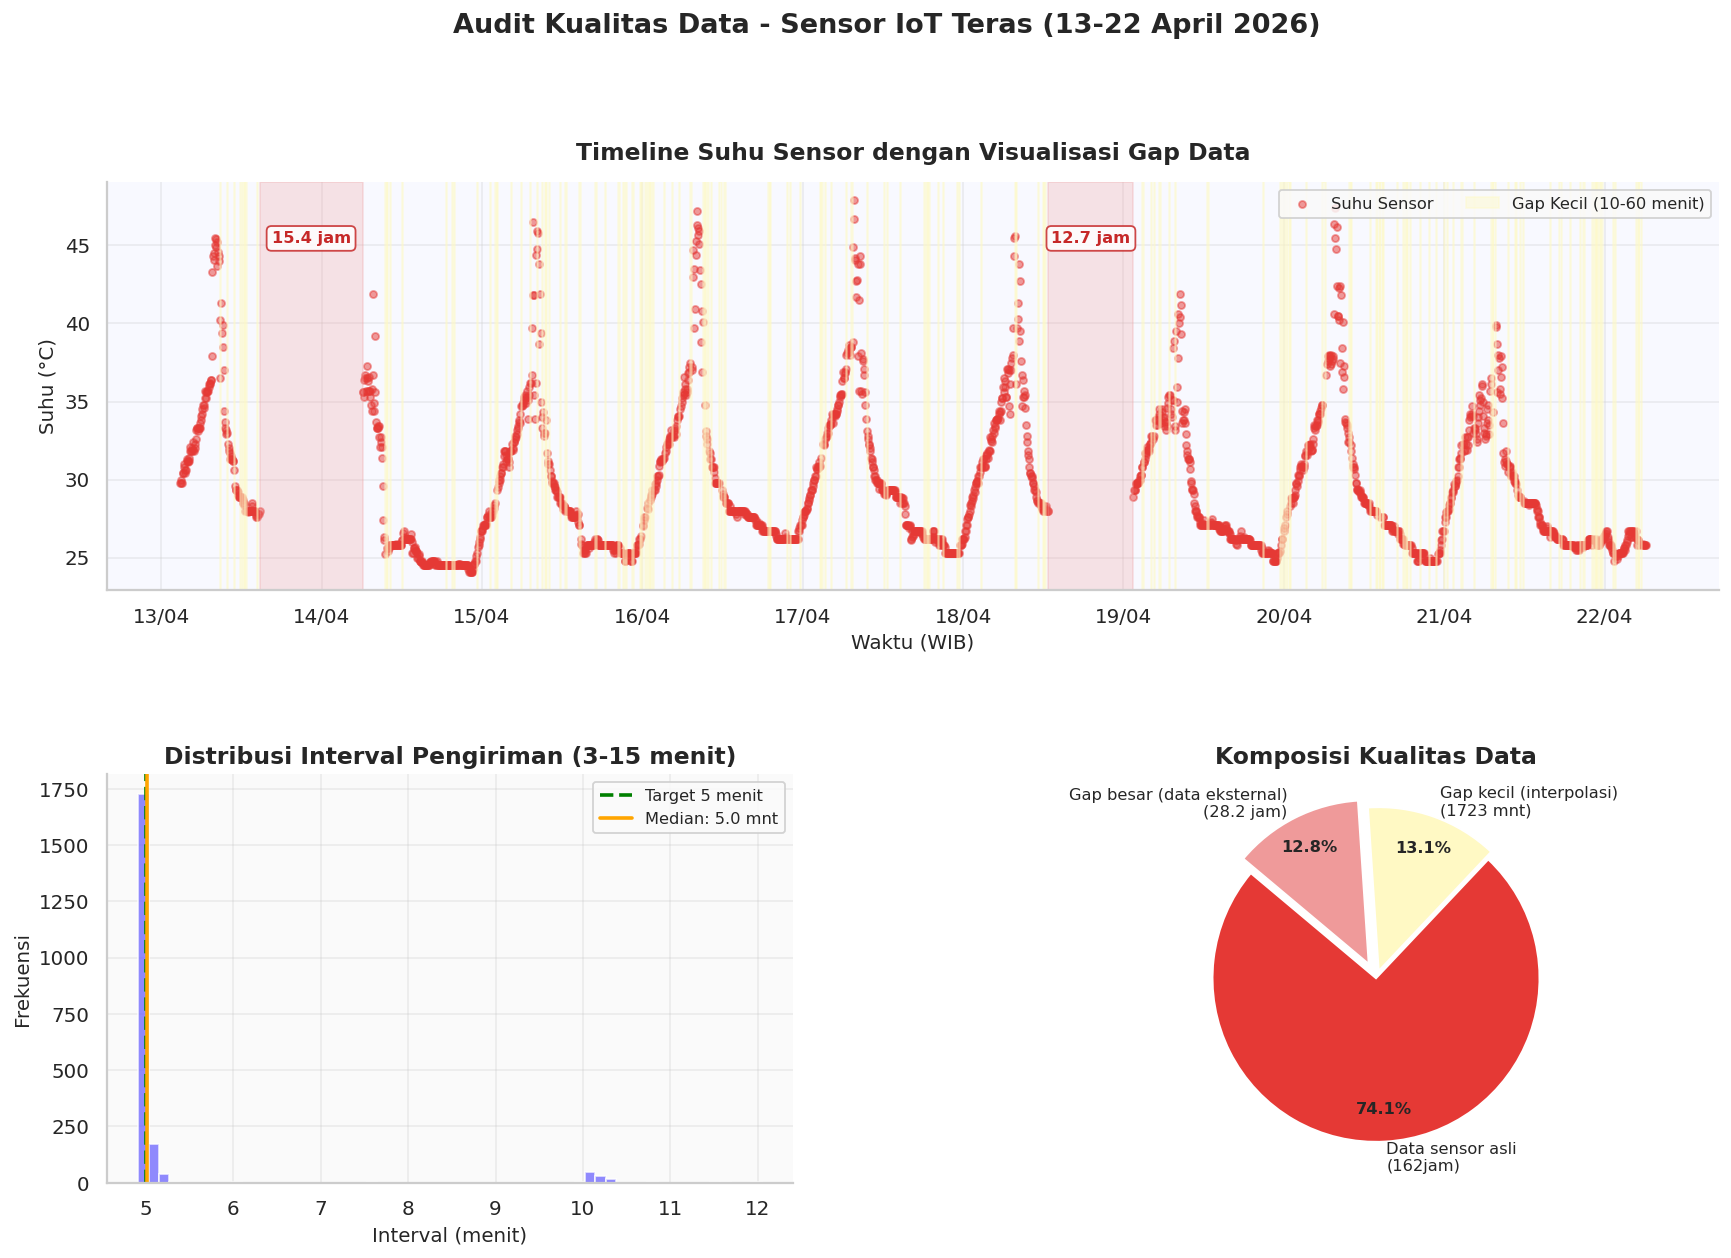

✅ Audit gaps done


In [5]:
# visualisasi gap audit
fig = plt.figure(figsize=(16,10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :]) # full width untuk timeline gap
ax2 = fig.add_subplot(gs[1, 0]) # distribusi interval
ax3 = fig.add_subplot(gs[1, 1]) # pie chart komposisi data

# plot 1
# timeline scatter dengan highlight gap
ax1.scatter(df.index, df['suhu'], s=15, alpha=0.5, color=PALETTE['suhu'], label='Suhu Sensor')
for _, row in big_gaps_df.iterrows():
  ax1.axvspan(row['start'], row['end'], alpha=0.25, color=PALETTE['gap_big'],
              label='Gap Besar (>1 jam)' if _ == small_gaps_df.index[0] else '')
for _, row in small_gaps_df.iterrows():
  ax1.axvspan(row['start'], row['end'], alpha=0.4, color=PALETTE['gap_sm'],
              label='Gap Kecil (10-60 menit)' if _ == small_gaps_df.index[0] else '')

ax1.set_title('Timeline Suhu Sensor dengan Visualisasi Gap Data', pad=12)
ax1.set_ylabel('Suhu (°C)')
ax1.set_xlabel('Waktu (WIB)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.legend(fontsize=9, ncol=3, loc='upper right')
ax1.set_facecolor('#F8F9FF')

# annotate big gaps
for _, row in big_gaps_df.iterrows():
  mid = row['start'] + (row['end'] - row['start']) / 2
  ax1.annotate(f"{row['gap_menit']/60:.1f} jam",
                 xy=(mid, ax1.get_ylim()[1]*0.92), ha='center', fontsize=9,
                 color='#C62828', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#C62828', alpha=0.85))

# plot 2 -> histogram interval
ax2.hist(q[(q>=3)&(q<=15)], bins=60, color=PALETTE['accent'], alpha=0.75, edgecolor='white')
ax2.axvline(5, color='green', ls='--', lw=2, label='Target 5 menit')
ax2.axvline(q.median(), color='orange', ls='-', lw=2, label=f'Median: {q.median():.1f} mnt')
ax2.set_title('Distribusi Interval Pengiriman (3-15 menit)')
ax2.set_xlabel('Interval (menit)')
ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=9)

# plot 3 -> pie chart komposisi data
total_menit_big = big_gaps_df['gap_menit'].sum()
total_menit_small = small_gaps_df['gap_menit'].sum()
total_menit_data = (df.index.max() - df.index.min()).total_seconds()/60
menit_asli = total_menit_data - total_menit_big - total_menit_small

sizes = [menit_asli, total_menit_small, total_menit_big]
labels = [f'Data sensor asli\n({menit_asli/60:.0f}jam)',
          f'Gap kecil (interpolasi)\n({total_menit_small:.0f} mnt)',
          f'Gap besar (data eksternal)\n({total_menit_big/60:.1f} jam)']
colors_pie = [PALETTE['suhu'], PALETTE['gap_sm'], PALETTE['gap_big']]
explode = (0, 0.05, 0.1)
wedges, texts, autotexts = ax3.pie(sizes, labels=labels, colors=colors_pie,
    autopct='%1.1f%%', explode=explode, startangle=140,
    textprops={'fontsize': 9}, pctdistance=0.8)
for at in autotexts: at.set_fontweight('bold')
ax3.set_title('Komposisi Kualitas Data')

fig.suptitle('Audit Kualitas Data - Sensor IoT Teras (13-22 April 2026)',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('fig_audit_gap.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Audit gaps done')

## 5. Optimasi Imputasi: Gabungkan Data Eksternal

### Strategi Imputasi Berdasarkan Tipe Gap

| Tipe Gap | Durasi | Sumber Pengisi | Alasan |
|----------|--------|----------------|--------|
| **Gap Besar** | > 60 menit | Data eksternal (Open-Meteo + Visual Crossing) | Interpolasi linear tidak valid untuk gap sepanjang 12–15 jam karena melewati siklus siang-malam penuh. Data cuaca eksternal memberikan estimasi fisik yang jauh lebih realistis. |
| **Gap Kecil** | 10–60 menit | Interpolasi linear | Gap singkat, perubahan gradual, aman diinterpolasi |
| **Jitter** | < 10 menit | Reindex + snap ke grid 5 menit | Normal; hanya perlu alignment grid |

### Metode Penggabungan Data Eksternal
Data eksternal tersedia per jam (hourly). Untuk mengisi sensor 5-menitan:  
1. **Upsample** data eksternal ke 5 menit dengan interpolasi kubik  
2. **Kalibrasi offset** — koreksi bias sistematis antara sensor teras (paparan langsung) dan stasiun referensi  
3. **Weighted blend** — kombinasi Open-Meteo dan Visual Crossing untuk mengurangi noise

In [6]:
# reindex sensor ke grid 5 menit
start    = df.index.min().floor('5min')
end      = df.index.max().ceil('5min')
full_idx = pd.date_range(start=start, end=end, freq='5min', tz='Asia/Jakarta')

df_full = df[['suhu','kelembapan','cahaya','cahaya_raw','kondisi']].reindex(
    full_idx, method='nearest', tolerance=pd.Timedelta('3min'))
df_full.index.name = 'timestamp'
df_full['is_original'] = ~df_full['suhu'].isna()

# Upsample data eksternal ke 5 menit
ext_idx = pd.date_range(start=full_idx.min(), end=full_idx.max(), freq='5min', tz='Asia/Jakarta')

om_5m = df_om_raw[['ext_suhu_om','ext_lembap_om','ext_rad_total_om','ext_awan_om']].reindex(
    ext_idx).interpolate('cubic').clip(lower=0)
vc_5m = df_vc_raw[['ext_suhu_vc','ext_lembap_vc','ext_solar_vc','ext_awan_vc',
                    'ext_angin_vc','ext_pressure_vc','ext_precipprob_vc']].reindex(
    ext_idx).interpolate('cubic').clip(lower=0)

# hitung offset kalibrasi pada periode dengan data asli
overlap = df_full[df_full['is_original']].join(om_5m).join(vc_5m).dropna()

if len(overlap) > 10:
    offset_suhu_om = (overlap['suhu'] - overlap['ext_suhu_om']).median()
    offset_lembap_om = (overlap['kelembapan'] - overlap['ext_lembap_om']).median()
    offset_suhu_vc = (overlap['suhu'] - overlap['ext_suhu_vc']).median()
    offset_lembap_vc = (overlap['kelembapan'] - overlap['ext_lembap_vc']).median()
else:
    offset_suhu_om = offset_lembap_om = offset_suhu_vc = offset_lembap_vc = 0

print('=== KALIBRASI OFFSET (Sensor - Referensi) ===')
print(f'  Suhu      : OM offset = {offset_suhu_om:+.2f} °C  |  VC offset = {offset_suhu_vc:+.2f} °C')
print(f'  Kelembapan: OM offset = {offset_lembap_om:+.2f} %   |  VC offset = {offset_lembap_vc:+.2f} %')

om_5m['ext_suhu_om_cal']   = om_5m['ext_suhu_om']   + offset_suhu_om
om_5m['ext_lembap_om_cal'] = om_5m['ext_lembap_om'] + offset_lembap_om
vc_5m['ext_suhu_vc_cal']   = vc_5m['ext_suhu_vc']   + offset_suhu_vc
vc_5m['ext_lembap_vc_cal'] = vc_5m['ext_lembap_vc'] + offset_lembap_vc

# Weighted blend: 50% OM + 50% VC
om_5m['imp_suhu']    = (om_5m['ext_suhu_om_cal']   + vc_5m['ext_suhu_vc_cal'])   / 2
om_5m['imp_lembap']  = (om_5m['ext_lembap_om_cal'] + vc_5m['ext_lembap_vc_cal']) / 2
om_5m['imp_cahaya']  = ((om_5m['ext_rad_total_om'] + vc_5m['ext_solar_vc']) / 2).clip(0, 4095)

print()
print('✅ Kalibrasi & blending selesai')

=== KALIBRASI OFFSET (Sensor - Referensi) ===
  Suhu      : OM offset = +1.50 °C  |  VC offset = +1.15 °C
  Kelembapan: OM offset = +6.60 %   |  VC offset = +4.53 %

✅ Kalibrasi & blending selesai


In [7]:
# identifikasi baris dlm gap besar
df_full['in_big_gap'] = False
for _, row in big_gaps_df.iterrows():
  mask = (df_full.index > row['start']) & (df_full.index < row['end'])
  df_full.loc[mask, 'in_big_gap'] = True

n_big_gap_rows = df_full['in_big_gap'].sum()
print(f'baris dalam gap besar (akan diisi eksternal): {n_big_gap_rows}')

# imputasi
df_full['suhu_imp_src'] = 'original'
df_full['lembap_imp_src'] = 'original'
df_full['cahaya_imp_src'] = 'original'

# gap besar -> isi dari data eksternal (blended)
gap_idx = df_full[df_full['in_big_gap'] & ~df_full['is_original']].index
df_full.loc[gap_idx, 'suhu'] = om_5m.loc[gap_idx, 'imp_suhu']
df_full.loc[gap_idx, 'kelembapan'] = om_5m.loc[gap_idx, 'imp_lembap']
df_full.loc[gap_idx, 'cahaya'] = om_5m.loc[gap_idx, 'imp_cahaya']
df_full.loc[gap_idx, 'suhu_imp_src'] = 'external'
df_full.loc[gap_idx, 'lembap_imp_src'] = 'external'
df_full.loc[gap_idx, 'cahaya_imp_src'] = 'external'

# gap kecil & sisa NaN: interpolasi linear
remaining_nan = df_full['suhu'].isna()
df_full.loc[remaining_nan, 'suhu_imp_src'] = 'interpolasi'
df_full.loc[remaining_nan, 'lembap_imp_src'] = 'interpolasi'
df_full.loc[remaining_nan, 'cahaya_imp_src'] = 'interpolasi'
df_full['suhu'] = df_full['suhu'].interpolate('linear')
df_full['kelembapan'] = df_full['kelembapan'].interpolate('linear')
df_full['cahaya'] = df_full['cahaya'].interpolate('linear')

# kondisi: forward fill
df_full['kondisi'] = df_full['kondisi'].ffill().bfill()

n_orig = df_full['is_original'].sum()
n_ext = (df_full['suhu_imp_src'] == 'external').sum()
n_interp = (df_full['suhu_imp_src'] == 'interpolasi').sum()
print('\n=== RINGKASAN IMPUTASI ===')
print(f'  Data asli (sensor)        : {n_orig:5d} baris ({n_orig/len(df_full)*100:.1f}%)')
print(f'  Diisi dari data eksternal : {n_ext:5d} baris ({n_ext/len(df_full)*100:.1f}%)')
print(f'  Diisi dari interpolasi    : {n_interp:5d} baris ({n_interp/len(df_full)*100:.1f}%)')
print(f'  Total timestep 5-menit   : {len(df_full)}')
print(f'\n  Missing tersisa: {df_full[["suhu","kelembapan","cahaya"]].isna().sum().sum()}')

baris dalam gap besar (akan diisi eksternal): 337

=== RINGKASAN IMPUTASI ===
  Data asli (sensor)        :  2119 baris (80.5%)
  Diisi dari data eksternal :   336 baris (12.8%)
  Diisi dari interpolasi    :   178 baris (6.8%)
  Total timestep 5-menit   : 2633

  Missing tersisa: 0


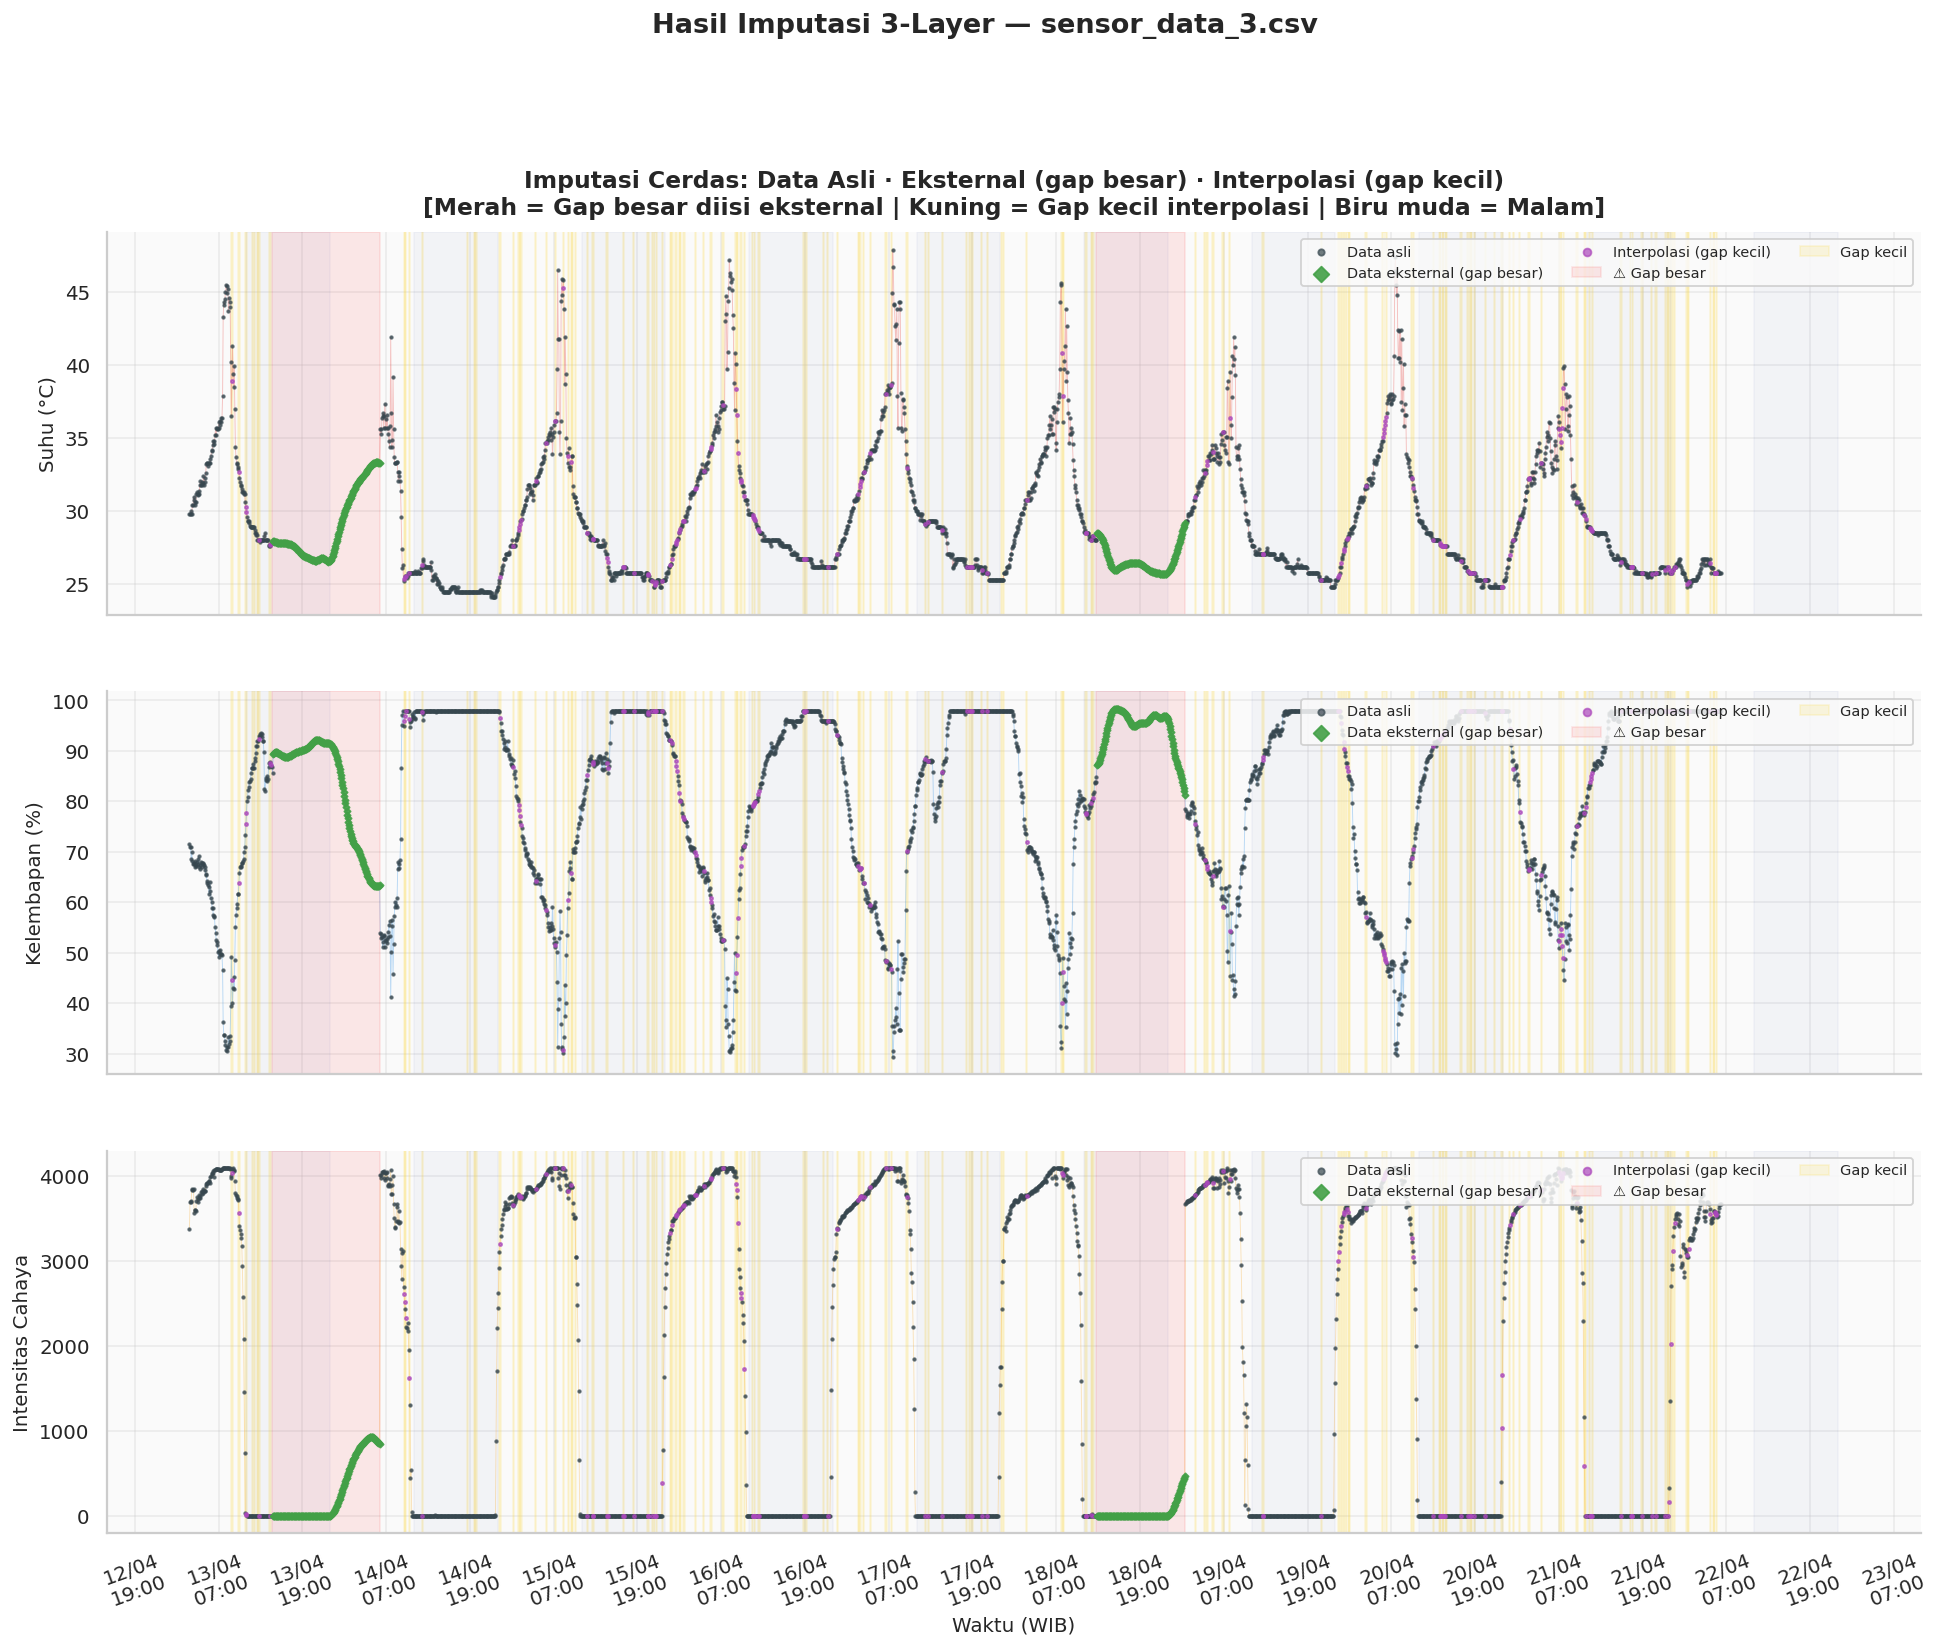

✅ visualization of imputation done


In [8]:
# visualisasi layer imputasi
fig, axes = plt.subplots(3, 1, figsize=(18, 13), sharex=True)
fig.patch.set_facecolor('white')

cols_cfg = [
    ('suhu',       PALETTE['suhu'],   'Suhu (°C)'),
    ('kelembapan', PALETTE['lembap'], 'Kelembapan (%)'),
    ('cahaya',     PALETTE['cahaya'], 'Intensitas Cahaya'),
]

for ax, (col, color, label) in zip(axes, cols_cfg):
  orig = df_full[df_full['suhu_imp_src']=='original']
  ext = df_full[df_full['suhu_imp_src']=='external']
  interp = df_full[df_full['suhu_imp_src']=='interpolasi']

  ax.plot(df_full.index, df_full[col], color=color, lw=0.5, alpha=0.3)
  ax.scatter(orig.index, orig[col], s=2, alpha=0.7, color='#37474F',zorder=4, label='Data asli')
  ax.scatter(ext.index, ext[col],s=6, alpha=0.9, color=PALETTE['ext'], zorder=5, label='Data eksternal (gap besar)', marker='D')
  ax.scatter(interp.index, interp[col], s=3, alpha=0.7, color='#AB47BC',zorder=4, label='Interpolasi (gap kecil)')

  # bg shading
  for _, row in big_gaps_df.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.08, color='red',
               label='⚠️ Gap besar' if _ == big_gaps_df.index[0] else '')
  for _, row in small_gaps_df.iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.15, color='#FDD835',
               label='Gap kecil' if _ == small_gaps_df.index[0] else '')

  # night shading
  for day in pd.date_range(df_full.index.min().date(), df_full.index.max().date()):
    night_start = pd.Timestamp(day, tz='Asia/Jakarta').replace(hour=18)
    night_end   = pd.Timestamp(day + pd.Timedelta('1d'), tz='Asia/Jakarta').replace(hour=6)
    ax.axvspan(night_start, night_end, alpha=0.04, color='#3949AB')

  ax.set_ylabel(label, fontsize=11)
  ax.legend(loc='upper right', fontsize=8, ncol=3, markerscale=2.5)
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
  ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))

axes[0].set_title(
    'Imputasi Cerdas: Data Asli · Eksternal (gap besar) · Interpolasi (gap kecil)\n'
    '[Merah = Gap besar diisi eksternal | Kuning = Gap kecil interpolasi | Biru muda = Malam]',
    pad=10)
axes[-1].set_xlabel('Waktu (WIB)')
plt.xticks(rotation=20)
fig.suptitle('Hasil Imputasi 3-Layer — sensor_data_3.csv', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('fig_imputasi.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ visualization of imputation done')

## 6. Feature Engineering

In [9]:
df_feat = df_full.copy()

# temporal
df_feat['jam']         = df_feat.index.hour
df_feat['menit']       = df_feat.index.minute
df_feat['hari_minggu'] = df_feat.index.dayofweek
df_feat['tanggal']     = df_feat.index.date
df_feat['hari_ke']     = (df_feat.index - df_feat.index.min()).total_seconds() / 86400

# siklus
df_feat['jam_sin'] = np.sin(2 * np.pi * df_feat['jam'] / 24)
df_feat['jam_cos'] = np.cos(2 * np.pi * df_feat['jam'] / 24)

# flag kontekstual
df_feat['is_malam']      = (df_feat['kondisi'] == 'GELAP').astype(int)
df_feat['is_siang_panas']= df_feat['jam'].apply(lambda h: 1 if 12 <= h <= 16 else 0)

# gabungkan fitur eksternal (untuk model)
df_feat = df_feat.join(om_5m[['ext_suhu_om','ext_lembap_om','ext_rad_total_om']], how='left')
df_feat = df_feat.join(vc_5m[['ext_solar_vc','ext_precipprob_vc','ext_angin_vc']], how='left')

cols_sensor = ['suhu', 'kelembapan', 'cahaya']

print('✅ Feature engineering done!')
print(f'   Total fitur tersedia: {len(df_feat.columns)}')
display(df_feat[['suhu','kelembapan','cahaya','jam','kondisi','is_malam',
                  'jam_sin','jam_cos','ext_suhu_om']].head(5))

✅ Feature engineering done!
   Total fitur tersedia: 25


,suhu,kelembapan,cahaya,jam,kondisi,is_malam,jam_sin,jam_cos,ext_suhu_om
timestamp,,,,,,,,,
2026-04-13 09:50:00+07:00,29.8,71.5,3384.0,9,TERANG,0,0.707107,-0.707107,NaN
2026-04-13 09:55:00+07:00,29.8,70.9,3695.0,9,TERANG,0,0.707107,-0.707107,NaN
2026-04-13 10:00:00+07:00,29.8,70.9,3695.0,10,TERANG,0,0.500000,-0.866025,30.200000
2026-04-13 10:05:00+07:00,30.0,68.5,3706.0,10,TERANG,0,0.500000,-0.866025,30.287783
2026-04-13 10:10:00+07:00,29.8,69.9,3835.0,10,TERANG,0,0.500000,-0.866025,30.364442


## 7. Exploratory Data Analysis (EDA)
### 7.1 Statistik Deskriptif

In [10]:
print('=== STATISTIK DESKRIPTIF ===')
display(df_feat[cols_sensor].describe().round(2))

print()
print('=== RENTANG PER HARI ===')
daily = df_feat.groupby('tanggal')[['suhu', 'kelembapan']].agg(['min', 'max', 'mean']).round(2)
display(daily)

=== STATISTIK DESKRIPTIF ===


,suhu,kelembapan,cahaya
count,2633.00,2633.00,2633.00
mean,29.43,81.50,1678.09
std,4.35,17.82,1830.13
min,24.10,29.40,0.00
25%,26.20,67.60,0.00
50%,28.00,88.50,73.00
75%,31.80,98.00,3747.00
max,47.90,98.35,4095.00



=== RENTANG PER HARI ===


suhu              kelembapan              
             min   max   mean        min    max   mean
tanggal                                               
2026-04-13  27.6  45.5  32.02       30.5  93.50  70.37
2026-04-14  24.5  41.9  28.71       41.2  98.00  83.74
2026-04-15  24.1  46.5  28.95       30.1  98.00  81.19
2026-04-16  24.8  47.2  30.02       30.4  98.00  79.53
2026-04-17  26.1  47.9  30.54       29.4  98.00  78.39
2026-04-18  25.3  45.6  29.50       31.1  98.35  82.33
2026-04-19  25.7  41.9  29.13       41.5  98.00  82.86
2026-04-20  24.8  47.4  29.83       29.7  98.00  78.84
2026-04-21  24.8  39.9  29.22       44.7  98.00  82.59
2026-04-22  24.8  26.7  25.90       98.0  98.00  98.00

### 7.2 Distribusi Univariat

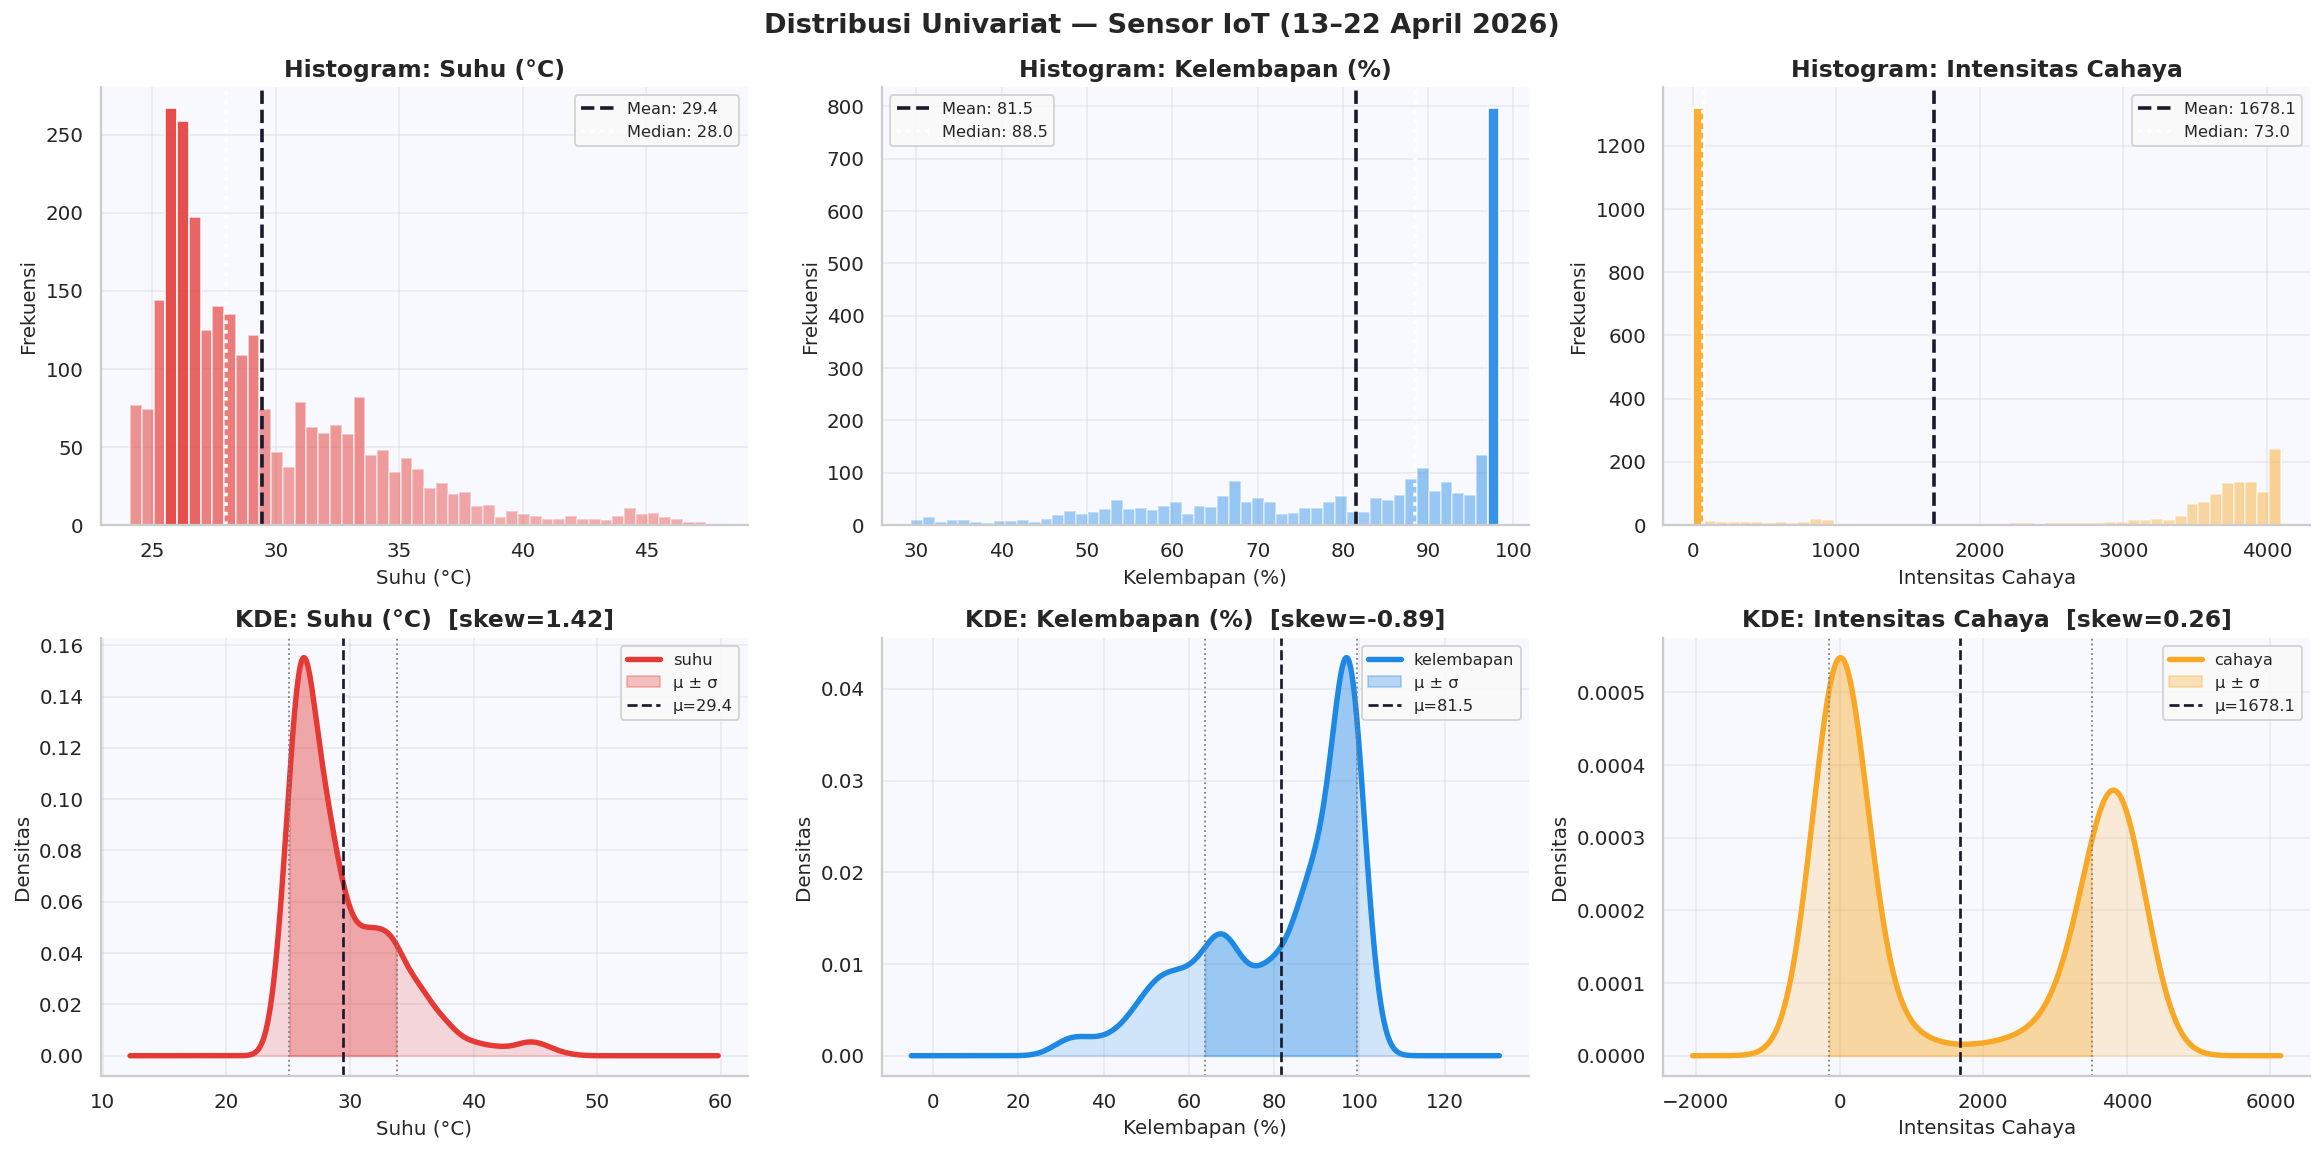

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.patch.set_facecolor('white')
colors_u = [PALETTE['suhu'], PALETTE['lembap'], PALETTE['cahaya']]
labels_u = ['Suhu (°C)', 'Kelembapan (%)', 'Intensitas Cahaya']

for i, (col, color, label) in enumerate(zip(cols_sensor, colors_u, labels_u)):
    # histogram
    ax0 = axes[0, i]
    n, bins, patches = ax0.hist(df_feat[col].dropna(), bins=50, color=color, alpha=0.7, edgecolor='white')
    ax0.axvline(df_feat[col].mean(),   color='#1A1A2E', ls='--', lw=2, label=f'Mean: {df_feat[col].mean():.1f}')
    ax0.axvline(df_feat[col].median(), color='white',   ls=':',  lw=2, label=f'Median: {df_feat[col].median():.1f}')
    ax0.set_title(f'Histogram: {label}')
    ax0.set_xlabel(label); ax0.set_ylabel('Frekuensi')
    ax0.legend(fontsize=9)
    ax0.set_facecolor('#F8F9FF')
    # gradient color bars
    norm_vals = (n - n.min()) / (n.max() - n.min() + 1e-9)
    for patch, nv in zip(patches, norm_vals):
        patch.set_alpha(0.4 + 0.5*nv)

    # KDE
    ax1 = axes[1, i]
    series = df_feat[col].dropna()
    series.plot(kind='kde', ax=ax1, color=color, lw=3)
    ax1.fill_between(ax1.lines[0].get_xdata(), ax1.lines[0].get_ydata(),
                     alpha=0.18, color=color)
    # shade mean ± std
    mu, sigma = series.mean(), series.std()
    xd = ax1.lines[0].get_xdata(); yd = ax1.lines[0].get_ydata()
    mask = (xd >= mu-sigma) & (xd <= mu+sigma)
    ax1.fill_between(xd, yd, where=mask, alpha=0.3, color=color, label='μ ± σ')
    ax1.axvline(mu,     color='#1A1A2E', ls='--', lw=1.5, label=f'μ={mu:.1f}')
    ax1.axvline(mu+sigma, color='gray', ls=':', lw=1)
    ax1.axvline(mu-sigma, color='gray', ls=':', lw=1)
    ax1.set_title(f'KDE: {label}  [skew={series.skew():.2f}]')
    ax1.set_xlabel(label); ax1.set_ylabel('Densitas')
    ax1.legend(fontsize=9)
    ax1.set_facecolor('#F8F9FF')

plt.suptitle('Distribusi Univariat — Sensor IoT (13–22 April 2026)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_univariat.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.3 Time-Series Story - Kisah 10 hari sensor IoT

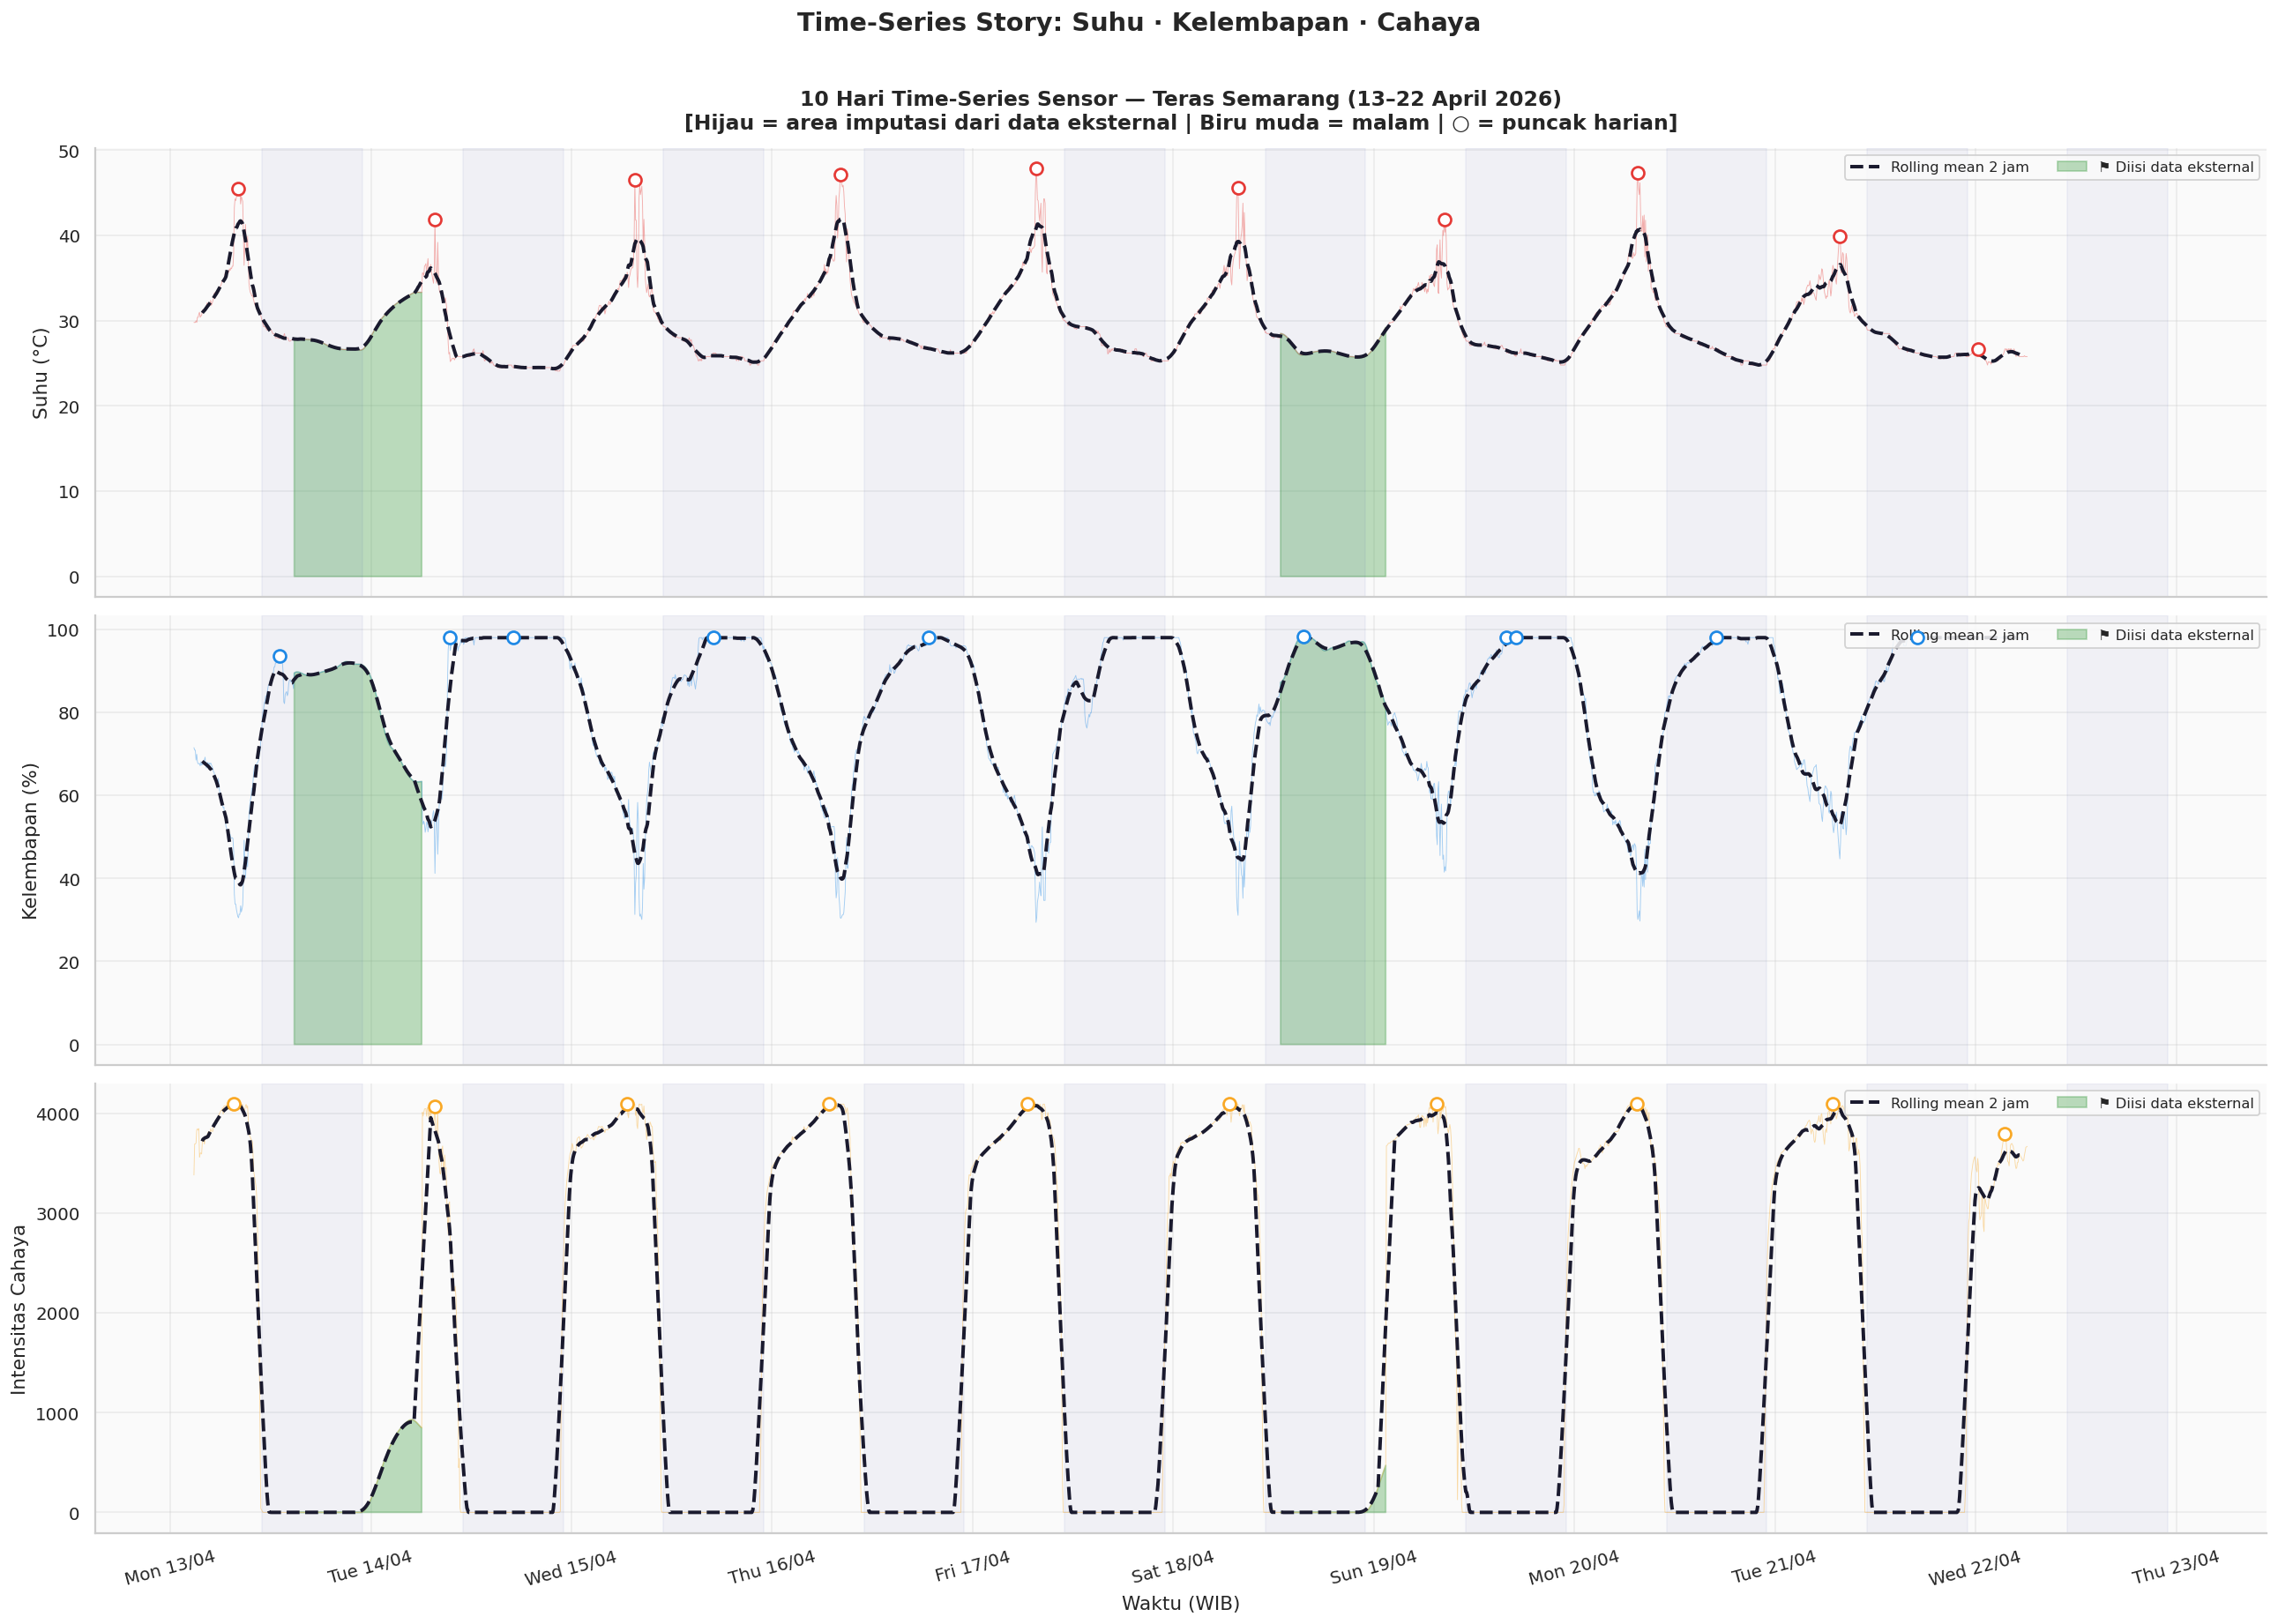

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(20, 14), sharex=True)
fig.patch.set_facecolor('white')
plot_cfg = [
    ('suhu', PALETTE['suhu'], 'Suhu (°C)'),
    ('kelembapan', PALETTE['lembap'], 'Kelembapan (%)'),
    ('cahaya', PALETTE['cahaya'], 'Intensitas Cahaya'),
]

for ax, (col, color, label) in zip(axes, plot_cfg):
    ax.plot(df_feat.index, df_feat[col], color=color, lw=0.5, alpha=0.4)
    rm = df_feat[col].rolling(24, center=True).mean()
    ax.plot(df_feat.index, rm, color=PALETTE['dark'], lw=2.2, ls='--', label='Rolling mean 2 jam', zorder=5)

    # imputation layer
    ext_mask  = df_feat['suhu_imp_src'] == 'external'
    ax.fill_between(df_feat.index, df_feat[col],
                    where=ext_mask, alpha=0.35, color=PALETTE['ext'],
                    label='🚩 Diisi data eksternal')

    # night shading
    for day in pd.date_range(df_feat.index.min().date(), df_feat.index.max().date()):
        ns = pd.Timestamp(day, tz='Asia/Jakarta').replace(hour=18)
        ne = pd.Timestamp(day + pd.Timedelta('1d'), tz='Asia/Jakarta').replace(hour=6)
        ax.axvspan(ns, ne, alpha=0.05, color='#3949AB')

    ax.set_ylabel(label, fontsize=12)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d/%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator())

    # daily range annotation
    for day in pd.date_range(df_feat.index.min().date(), df_feat.index.max().date()):
        day_ts = pd.Timestamp(day, tz='Asia/Jakarta')
        day_data = df_feat.loc[df_feat.index.date == day.date(), col].dropna()
        if len(day_data) > 10:
            peak_t = day_data.idxmax(); peak_v = day_data.max()
            ax.scatter([peak_t], [peak_v], s=60, color='white', edgecolors=color, zorder=6, lw=1.5)

axes[0].set_title(
    '10 Hari Time-Series Sensor — Teras Semarang (13–22 April 2026)\n'
    '[Hijau = area imputasi dari data eksternal | Biru muda = malam | ○ = puncak harian]',
    pad=12)
axes[-1].set_xlabel('Waktu (WIB)', fontsize=12)
plt.xticks(rotation=15)
fig.suptitle('Time-Series Story: Suhu · Kelembapan · Cahaya', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_timeseries_story.png', dpi=130, bbox_inches='tight')
plt.show()


### 7.4 Pola Diurnal Per Jam

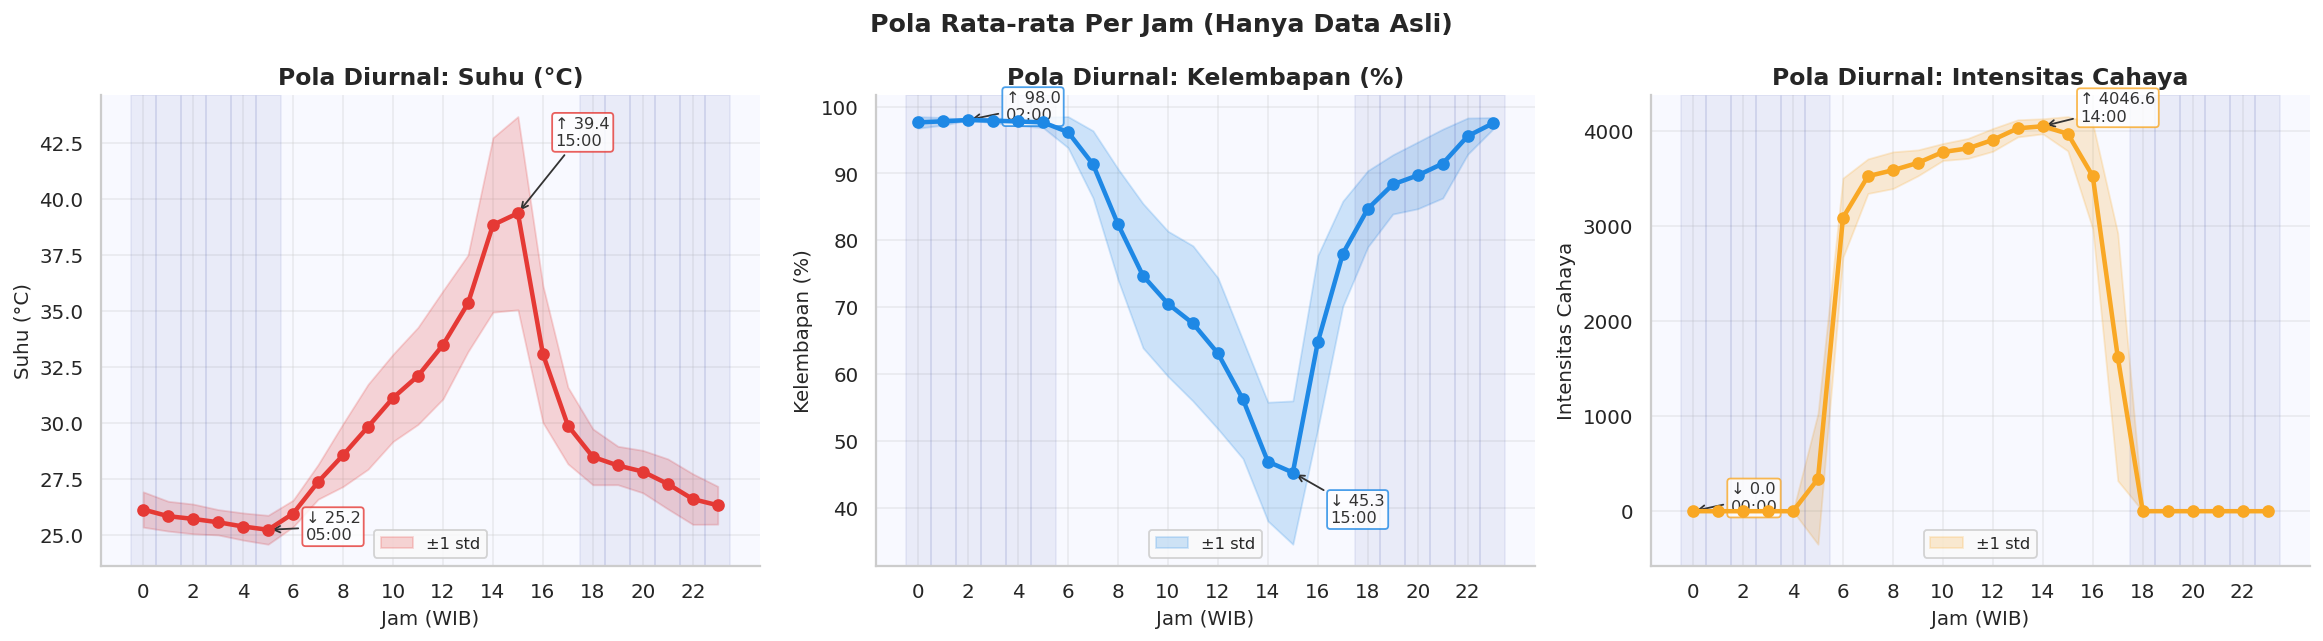

In [13]:
# only using original data for diurnal
df_orig = df_feat[df_feat['is_original'] == True].copy()
hourly = df_orig.groupby('jam')[cols_sensor].agg(['mean','std'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
colors_d = [PALETTE['suhu'], PALETTE['lembap'], PALETTE['cahaya']]
labels_d = ['Suhu (°C)', 'Kelembapan (%)', 'Intensitas Cahaya']
jam = np.arange(24)

for ax, col, color, label in zip(axes, cols_sensor, colors_d, labels_d):
    mean_v = hourly[col]['mean'].values
    std_v = hourly[col]['std'].values
    ax.plot(jam, mean_v, color=color, lw=2.5, marker='o', markersize=6, zorder=4)
    ax.fill_between(jam, mean_v-std_v, mean_v+std_v, alpha=0.2, color=color, label='±1 std')

    # gradient night shading
    for h in range(24):
        if h >= 18 or h < 6:
            ax.axvspan(h-0.5, h+0.5, alpha=0.08, color='#3949AB')

    # Annotate peak & trough
    peak_h = jam[np.argmax(mean_v)]; peak_v = mean_v.max()
    low_h  = jam[np.argmin(mean_v)]; low_v = mean_v.min()
    ax.annotate(f'↑ {peak_v:.1f}\n{peak_h:02d}:00', xy=(peak_h, peak_v),
                xytext=(peak_h+1.5, peak_v+std_v[peak_h]*0.7),
                arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9, color='#333',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))
    ax.annotate(f'↓ {low_v:.1f}\n{low_h:02d}:00', xy=(low_h, low_v),
                xytext=(low_h+1.5, low_v-std_v[low_h]*0.7),
                arrowprops=dict(arrowstyle='->', color='#333'), fontsize=9, color='#333',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=color, alpha=0.8))

    ax.set_title(f'Pola Diurnal: {label}')
    ax.set_xlabel('Jam (WIB)'); ax.set_ylabel(label)
    ax.set_xticks(range(0,24,2)); ax.legend(fontsize=9)
    ax.set_facecolor('#F8F9FF')

plt.suptitle('Pola Rata-rata Per Jam (Hanya Data Asli)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_diurnal.png', dpi=130, bbox_inches='tight')
plt.show()

### 7.5 Analisis Bivariat & Multivariat

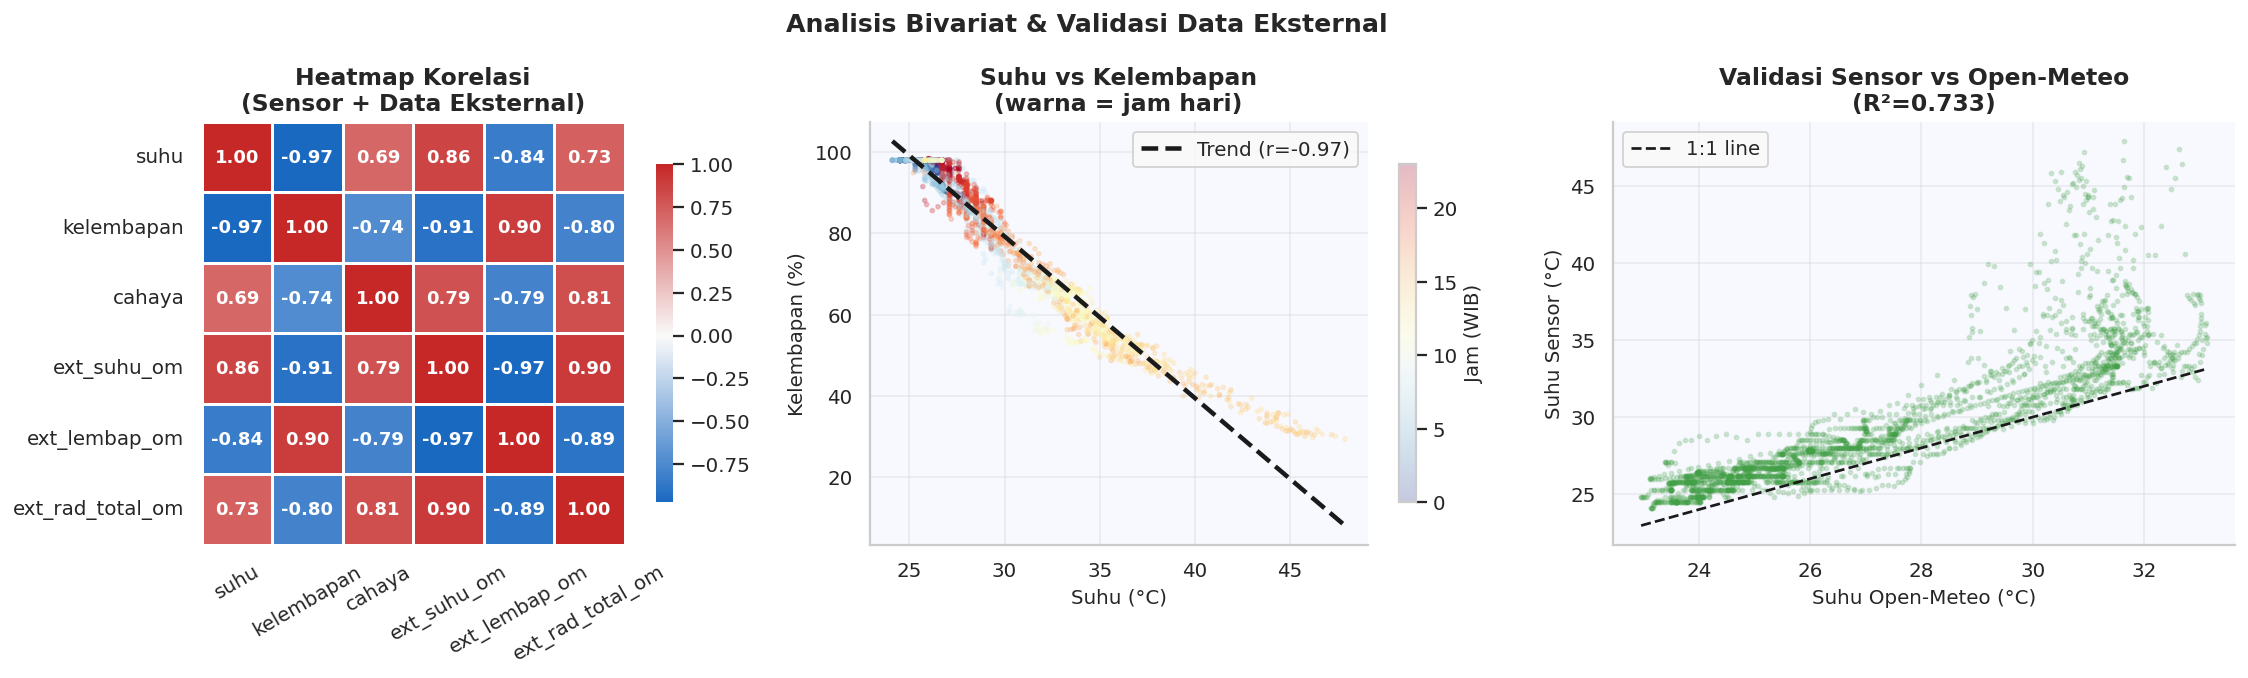

Korelasi Suhu-Kelembapan : r = -0.970
Korelasi Suhu-Cahaya     : r = 0.692
Sensor vs OM Suhu        : R² = 0.733


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# 1. Heatmap korelasi
corr = df_feat[cols_sensor + ['ext_suhu_om','ext_lembap_om','ext_rad_total_om']].corr()
mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap_corr = LinearSegmentedColormap.from_list('corr', ['#1565C0','#FAFAFA','#C62828'])
sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap_corr, center=0,
            ax=axes[0], square=True, linewidths=1.5,
            annot_kws={'size': 10, 'weight': 'bold'}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Heatmap Korelasi\n(Sensor + Data Eksternal)')
axes[0].tick_params(axis='x', rotation=30)

# 2. Scatter suhu vs kelembapan colored by jam
sc2 = axes[1].scatter(df_feat['suhu'], df_feat['kelembapan'],
                      c=df_feat['jam'], cmap='RdYlBu_r', alpha=0.25, s=5)
plt.colorbar(sc2, ax=axes[1], label='Jam (WIB)', shrink=0.8)
coef = np.polyfit(df_feat['suhu'].dropna(), df_feat['kelembapan'].dropna(), 1)
xl = np.linspace(df_feat['suhu'].min(), df_feat['suhu'].max(), 100)
axes[1].plot(xl, np.polyval(coef, xl), 'k--', lw=2.5, label=f'Trend (r={corr.loc["suhu","kelembapan"]:.2f})')
axes[1].set_xlabel('Suhu (°C)'); axes[1].set_ylabel('Kelembapan (%)')
axes[1].set_title(f'Suhu vs Kelembapan\n(warna = jam hari)')
axes[1].legend(); axes[1].set_facecolor('#F8F9FF')

# 3. Sensor vs External suhu
axes[2].scatter(df_feat['ext_suhu_om'], df_feat['suhu'], alpha=0.2, s=5, color=PALETTE['ext'])
x_ref = np.linspace(df_feat['ext_suhu_om'].min(), df_feat['ext_suhu_om'].max(), 100)
axes[2].plot(x_ref, x_ref, 'k--', lw=1.5, label='1:1 line')
r2_om = np.corrcoef(df_feat['ext_suhu_om'].dropna(),
                     df_feat.loc[df_feat['ext_suhu_om'].notna(),'suhu'].dropna())[0,1]**2
axes[2].set_xlabel('Suhu Open-Meteo (°C)'); axes[2].set_ylabel('Suhu Sensor (°C)')
axes[2].set_title(f'Validasi Sensor vs Open-Meteo\n(R²={r2_om:.3f})')
axes[2].legend(); axes[2].set_facecolor('#F8F9FF')

plt.suptitle('Analisis Bivariat & Validasi Data Eksternal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_bivariat.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Korelasi Suhu-Kelembapan : r = {corr.loc["suhu","kelembapan"]:.3f}')
print(f'Korelasi Suhu-Cahaya     : r = {corr.loc["suhu","cahaya"]:.3f}')
print(f'Sensor vs OM Suhu        : R² = {r2_om:.3f}')

### 7.6 Heatmap Multivariat (Jam x Tanggal)

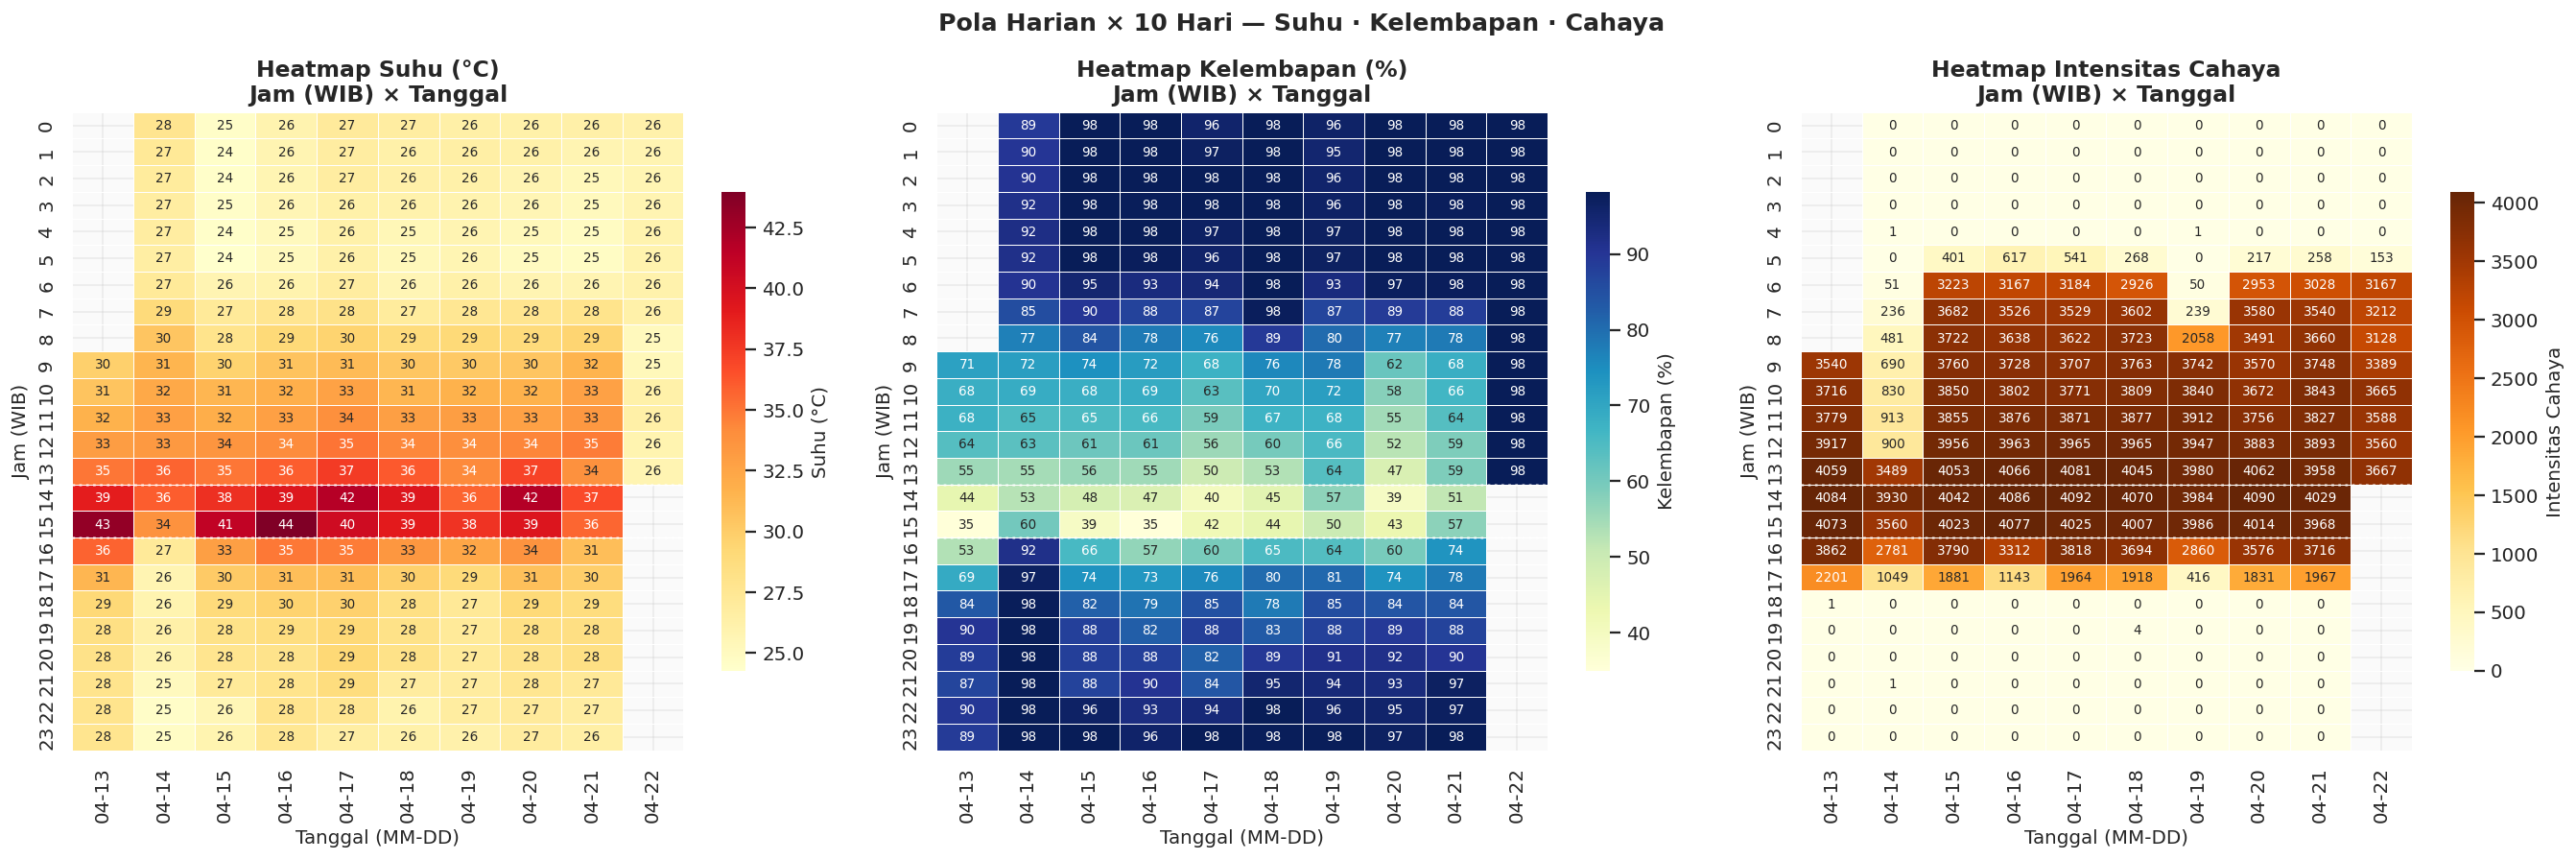

In [19]:
df_feat['tgl_str'] = df_feat['tanggal'].astype(str).str[5:]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('white')
pivot_data = [
    (df_feat.pivot_table('suhu', 'jam','tgl_str','mean'), 'YlOrRd', 'Suhu (°C)'),
    (df_feat.pivot_table('kelembapan', 'jam','tgl_str','mean'), 'YlGnBu', 'Kelembapan (%)'),
    (df_feat.pivot_table('cahaya', 'jam','tgl_str','mean'), 'YlOrBr', 'Intensitas Cahaya'),
]

for ax, (pivot, cmap, label) in zip(axes, pivot_data):
    sns.heatmap(pivot, cmap=cmap, ax=ax, linewidths=0.4,
                annot=True, fmt='.0f', annot_kws={'size': 7.5},
                cbar_kws={'label': label, 'shrink': 0.75})
    ax.set_title(f'Heatmap {label}\nJam (WIB) × Tanggal')
    ax.set_xlabel('Tanggal (MM-DD)'); ax.set_ylabel('Jam (WIB)')
    # highlight peak hours
    ax.axhline(y=14, color='white', ls=':', lw=1.5, alpha=0.6)
    ax.axhline(y=16, color='white', ls=':', lw=1.5, alpha=0.6)

plt.suptitle('Pola Harian × 10 Hari — Suhu · Kelembapan · Cahaya', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap_multivariat.png', dpi=130, bbox_inches='tight')
plt.show()